# 03 — Exponential Indifference Model

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

/Users/aarohi_verma/Downloads/final_project/ICCS2026_Final_Project


### 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from src.config import DATA_DIR
from src.data_loader import load_all_participants
from src.preprocessing import get_split, combine_participants
from src.discounting import add_subjective_values

from src.rt_models import predict_rt_exponential

### 2. Load and Prepare Data

In [3]:
participants = load_all_participants(DATA_DIR)

In [4]:
train = get_split(participants, "train")
test = get_split(participants, "test")

combined_train = combine_participants(train)
combined_test = combine_participants(test)

print("Train:", combined_train.shape)
print("Test:", combined_test.shape)

Train: (8920, 8)
Test: (20070, 8)


In [5]:
combined_train = add_subjective_values(
    combined_train,
    k=0.01
)

combined_test = add_subjective_values(
    combined_test,
    k=0.01
)

print("Training columns:")
print(combined_train.columns.tolist())

print("\nTest columns:")
print(combined_test.columns.tolist())

Training columns:
['immOutcome', 'delOutcome', 'delay', 'choice', 'p_imm', 'condition', 'RT', 'participant', 'SV_immediate', 'SV_delayed', 'value_difference']

Test columns:
['immOutcome', 'delOutcome', 'delay', 'choice', 'p_imm', 'condition', 'RT', 'participant', 'SV_immediate', 'SV_delayed', 'value_difference']


### 3. Data Quality Check

Before fitting the model, we check for missing values in reaction time and subjective value difference.

In [6]:
print("Missing values in training data:")
print(
    combined_train[["RT", "value_difference"]]
    .isnull()
    .sum()
)

print("\nMissing values in test data:")
print(
    combined_test[["RT", "value_difference"]]
    .isnull()
    .sum()
)

Missing values in training data:
RT                  34
value_difference     0
dtype: int64

Missing values in test data:
RT                  59
value_difference    60
dtype: int64


### 4. Reaction Time Exploration

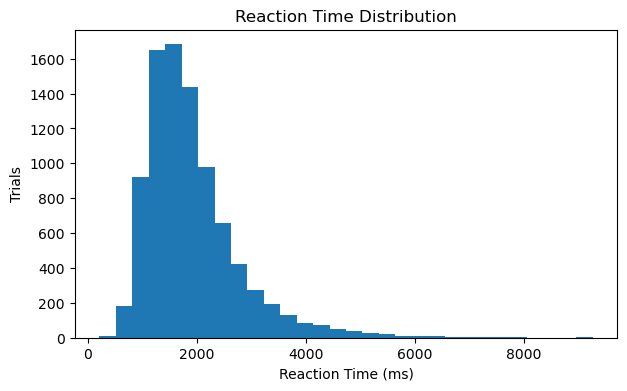

In [7]:
plt.figure(figsize=(7, 4))

plt.hist(
    combined_train["RT"].dropna(),
    bins=30
)

plt.xlabel("Reaction Time (ms)")
plt.ylabel("Trials")
plt.title("Reaction Time Distribution")

plt.show()

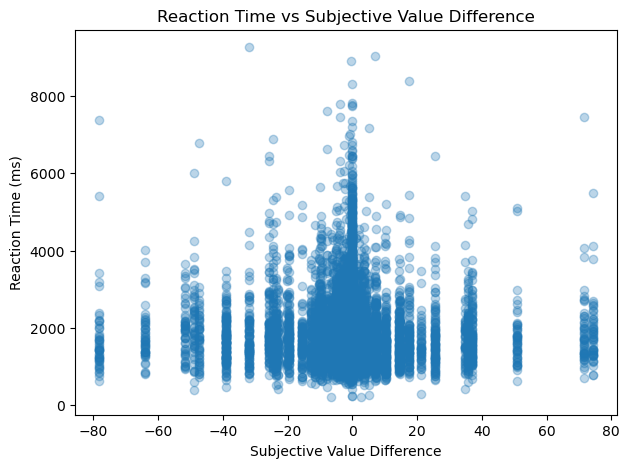

In [8]:
plt.figure(figsize=(7, 5))

plt.scatter(
    combined_train["value_difference"],
    combined_train["RT"],
    alpha=0.3
)

plt.xlabel("Subjective Value Difference")
plt.ylabel("Reaction Time (ms)")
plt.title("Reaction Time vs Subjective Value Difference")

plt.show()

## 5. Exponential Indifference Model

The Exponential Indifference Model assumes that reaction times decrease as the
absolute difference in subjective value increases. The expected log reaction
time is defined as:

\[
\mu_i =
a + b\exp(-c|\Delta SV_i|)
\]

where \(a\) is the baseline log reaction time, \(b\) controls the magnitude of
the indifference effect, and \(c\) controls how quickly the effect decreases
with increasing subjective-value difference.

To account for the positive and right-skewed nature of reaction times, the model
uses a Gaussian likelihood on log-transformed reaction times:

\[
\log(RT_i) \sim \mathcal{N}(\mu_i,\sigma^2)
\]

where \(\sigma\) represents residual variability on the log-RT scale.

Predicted mean reaction times in milliseconds are obtained by transforming the
predicted log reaction times back to the original scale:

\[
\widehat{RT}_i = \exp(\widehat{\log RT}_i)
\]

In [9]:
def predict_log_rt_exponential(value_difference, a, b, c):
    return (
        a
        + b * np.exp(
            -c * np.abs(value_difference)
        )
    )


def predict_rt_exponential(value_difference, a, b, c, sigma):
    predicted_log_rt = predict_log_rt_exponential(
        value_difference,
        a,
        b,
        c
    )

    return np.exp(
        predicted_log_rt + 0.5 * sigma**2
    )

In [10]:
def rt_negative_log_likelihood(params, df):

    a, b, c, sigma = params

    if sigma <= 0:
        return np.inf

    value_difference = df["value_difference"].to_numpy()
    observed_rt = df["RT"].to_numpy()

    if np.any(observed_rt <= 0):
        return np.inf

    observed_log_rt = np.log(observed_rt)

    predicted_log_rt = predict_log_rt_exponential(
        value_difference,
        a,
        b,
        c
    )

    residuals = observed_log_rt - predicted_log_rt

    nll = (
        0.5 * np.log(2 * np.pi * sigma**2)
        + (residuals**2) / (2 * sigma**2)
    )

    return np.mean(nll)

In [11]:
def fit_exponential_rt_model(df):

    df = df.dropna(
        subset=["RT", "value_difference"]
    ).copy()

    df = df[df["RT"] > 0].copy()

    result = minimize(
        rt_negative_log_likelihood,

        x0=[
            np.log(1000),
            0.5,
            0.01,
            0.3
        ],

        args=(df,),

        bounds=[
            (np.log(100), np.log(5000)),
            (0.001, 5),
            (0.000001, 20),
            (0.01, 2)
        ],

        method="L-BFGS-B"
    )

    return result

In [12]:
train_model_data = combined_train.dropna(
    subset=[
        "RT",
        "value_difference"
    ]
).copy()

train_model_data = train_model_data[
    train_model_data["RT"] > 0
].copy()

print(
    "Training observations used:",
    len(train_model_data)
)

Training observations used: 8886


In [13]:
result = fit_exponential_rt_model(train_model_data)

print("Optimization successful:", result.success)

print("Message:", result.message)

Optimization successful: True
Message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL


In [14]:
exp_a, exp_b, exp_c, exp_sigma = result.x

print(f"a     = {exp_a:.6f}  (log-RT scale)")
print(f"b     = {exp_b:.6f}  (log-RT scale)")
print(f"c     = {exp_c:.6f}")
print(f"sigma = {exp_sigma:.6f}  (log-RT scale)")

a     = 7.429356  (log-RT scale)
b     = 0.155439  (log-RT scale)
c     = 10.390906
sigma = 0.407834  (log-RT scale)


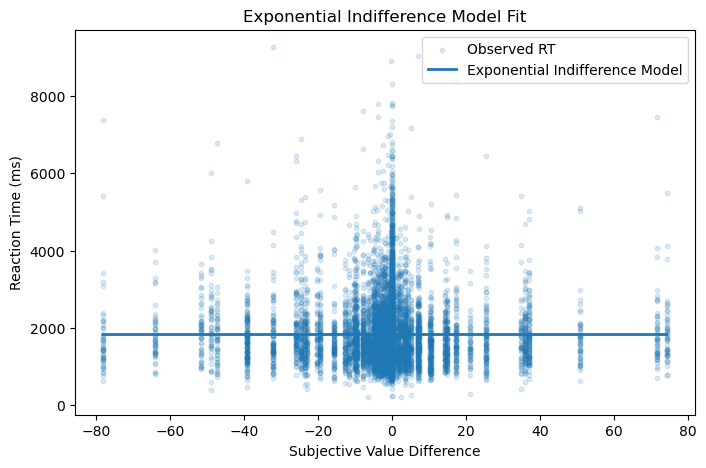

In [15]:
x = np.linspace(
    train_model_data["value_difference"].min(),
    train_model_data["value_difference"].max(),
    300)

y = predict_rt_exponential(x, exp_a, exp_b, exp_c, exp_sigma)

plt.figure(figsize=(8, 5))

plt.scatter(
    train_model_data["value_difference"],
    train_model_data["RT"],
    alpha=0.15,
    s=10,
    label="Observed RT")

plt.plot(
    x,
    y,
    linewidth=2,
    label="Exponential Indifference Model")

plt.xlabel("Subjective Value Difference")
plt.ylabel("Reaction Time (ms)")
plt.title("Exponential Indifference Model Fit")
plt.legend()

plt.show()

## 6. Out-of-Sample Prediction

In [16]:
test_pred = combined_test.copy()

test_pred["predicted_RT"] = predict_rt_exponential(
    test_pred["value_difference"],
    exp_a,
    exp_b,
    exp_c,
    exp_sigma
)

test_pred[["RT", "value_difference", "predicted_RT"]].head()

,RT,value_difference,predicted_RT
0,1507.5,-0.608925,1831.330122
1,1260.5,3.045789,1830.821536
2,2113.5,7.976316,1830.821536
3,1764.1,1.957143,1830.821536
4,1984.3,-0.795385,1830.894797


In [17]:
evaluation = test_pred.dropna(
    subset=[
        "RT",
        "predicted_RT"]).copy()

print("Test observations before evaluation:",len(test_pred))

print("Test observations used for evaluation:",len(evaluation))

Test observations before evaluation: 20070
Test observations used for evaluation: 19952


In [18]:
y_true = evaluation["RT"]
y_pred = evaluation["predicted_RT"]

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))

r2 = r2_score(y_true, y_pred)

print(f"MAE:  {mae:.2f} ms")
print(f"RMSE: {rmse:.2f} ms")
print(f"R²:   {r2:.4f}")

MAE:  688.94 ms
RMSE: 932.95 ms
R²:   -0.0236


In [19]:
log_y_true = np.log(y_true)
log_y_pred = np.log(y_pred)

log_rt_mse = mean_squared_error(
    log_y_true,
    log_y_pred
)

print(f"Log-RT MSE: {log_rt_mse:.6f}")

Log-RT MSE: 0.283734


In [20]:
baseline_mean = train_model_data["RT"].mean()

baseline_pred = np.full(len(evaluation), baseline_mean)

baseline_mae = mean_absolute_error(y_true, baseline_pred)

baseline_rmse = np.sqrt(mean_squared_error(y_true, baseline_pred))

baseline_r2 = r2_score(y_true, baseline_pred)

print(f"Mean RT baseline: {baseline_mean:.2f} ms")
print(f"Baseline MAE:     {baseline_mae:.2f} ms")
print(f"Baseline RMSE:    {baseline_rmse:.2f} ms")
print(f"Baseline R²:      {baseline_r2:.4f}")

Mean RT baseline: 1913.05 ms
Baseline MAE:     714.47 ms
Baseline RMSE:    944.67 ms
Baseline R²:      -0.0495


In [21]:
results = pd.DataFrame({
    "Model": ["Mean RT Baseline", "Exponential Indifference Model"],
    "MAE": [baseline_mae, mae],
    "RMSE": [baseline_rmse, rmse],
    "R2": [baseline_r2, r2]})

results

,Model,MAE,RMSE,R2
0,Mean RT Baseline,714.465627,944.669615,-0.049470
1,Exponential Indifference Model,688.943288,932.953110,-0.023598


In [22]:
mae_improvement = (
    (baseline_mae - mae) / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - rmse) / baseline_rmse
) * 100

print(f"MAE improvement:  {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

MAE improvement:  3.57%
RMSE improvement: 1.24%


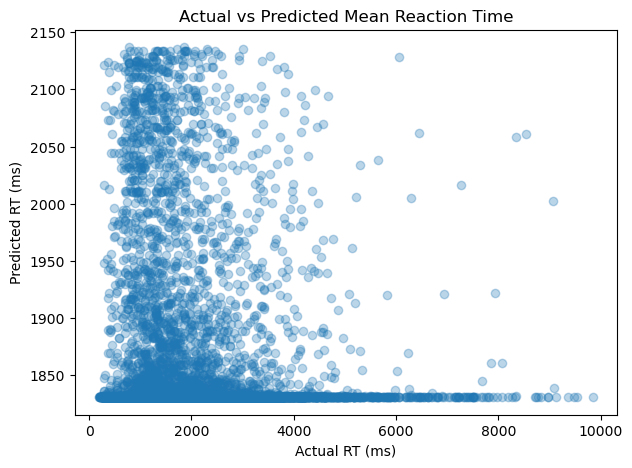

In [23]:
plt.figure(figsize=(7, 5))

plt.scatter(y_true, y_pred, alpha=0.3)

plt.xlabel("Actual RT (ms)")
plt.ylabel("Predicted RT (ms)")
plt.title("Actual vs Predicted Mean Reaction Time")

plt.show()

## 7. Parameter Recovery

Parameter recovery evaluates whether the Exponential Indifference Model can recover known parameters from simulated reaction-time data.

In [24]:
def simulate_exponential_rt(
    n_trials,
    a,
    b,
    c,
    sigma,
    seed=None
):

    rng = np.random.default_rng(seed)

    value_difference = rng.uniform(
        -10,
        10,
        n_trials
    )

    expected_log_rt = predict_log_rt_exponential(
        value_difference,
        a,
        b,
        c
    )

    log_rt = (
        expected_log_rt
        + rng.normal(
            0,
            sigma,
            n_trials
        )
    )

    RT = np.exp(log_rt)

    return pd.DataFrame({
        "value_difference": value_difference,
        "RT": RT
    })

In [25]:
recovery_profiles = [

    {
        "name": "Low indifference sensitivity",
        "a": np.log(900),
        "b": 0.50,
        "c": 0.002,
        "sigma": 0.20
    },

    {
        "name": "Intermediate",
        "a": np.log(1000),
        "b": 0.70,
        "c": 0.005,
        "sigma": 0.30
    },

    {
        "name": "High indifference sensitivity",
        "a": np.log(1200),
        "b": 0.90,
        "c": 0.010,
        "sigma": 0.40
    }
]

recovery_profiles

[{'name': 'Low indifference sensitivity',
  'a': 6.802394763324311,
  'b': 0.5,
  'c': 0.002,
  'sigma': 0.2},
 {'name': 'Intermediate',
  'a': 6.907755278982137,
  'b': 0.7,
  'c': 0.005,
  'sigma': 0.3},
 {'name': 'High indifference sensitivity',
  'a': 7.090076835776092,
  'b': 0.9,
  'c': 0.01,
  'sigma': 0.4}]

In [26]:
recovery_results = []

n_repeats = 10
n_trials = 1000

for profile in recovery_profiles:

    for repetition in range(n_repeats):

        simulated_data = simulate_exponential_rt(
            n_trials=n_trials,
            a=profile["a"],
            b=profile["b"],
            c=profile["c"],
            sigma=profile["sigma"],
            seed=repetition
        )

        fitted = fit_exponential_rt_model(simulated_data)

        recovered_a, recovered_b, recovered_c, recovered_sigma = fitted.x

        recovery_results.append({
            "profile": profile["name"],
            "true_a": profile["a"],
            "true_b": profile["b"],
            "true_c": profile["c"],
            "true_sigma": profile["sigma"],
            "recovered_a": recovered_a,
            "recovered_b": recovered_b,
            "recovered_c": recovered_c,
            "recovered_sigma": recovered_sigma,
            "successful": fitted.success
        })

recovery_df = pd.DataFrame(recovery_results)

print("Successful fits:",
      recovery_df["successful"].sum(),
      "out of",
      len(recovery_df))

Successful fits: 30 out of 30


In [27]:
recovery_df[
    [
        "profile",
        "true_a",
        "recovered_a",
        "true_b",
        "recovered_b",
        "true_c",
        "recovered_c",
        "true_sigma",
        "recovered_sigma"
    ]
].round(4)

,profile,true_a,recovered_a,true_b,recovered_b,true_c,recovered_c,true_sigma,recovered_sigma
0,Low indifference sensitivity,6.8024,6.8507,0.5,0.4444,0.002,0.0000,0.2,0.2051
1,Low indifference sensitivity,6.8024,6.8596,0.5,0.4528,0.002,0.0043,0.2,0.2058
2,Low indifference sensitivity,6.8024,6.8454,0.5,0.4379,0.002,0.0023,0.2,0.1961
3,Low indifference sensitivity,6.8024,6.8546,0.5,0.4485,0.002,0.0007,0.2,0.1969
4,Low indifference sensitivity,6.8024,6.8542,0.5,0.4476,0.002,0.0000,0.2,0.1946
5,Low indifference sensitivity,6.8024,6.8564,0.5,0.4495,0.002,0.0000,0.2,0.1929
6,Low indifference sensitivity,6.8024,6.8656,0.5,0.4591,0.002,0.0061,0.2,0.2034
7,Low indifference sensitivity,6.8024,6.8515,0.5,0.4445,0.002,0.0000,0.2,0.2036
8,Low indifference sensitivity,6.8024,6.8477,0.5,0.4431,0.002,0.0000,0.2,0.2028
9,Low indifference sensitivity,6.8024,6.8600,0.5,0.4541,0.002,0.0050,0.2,0.2008


In [28]:
from scipy.stats import pearsonr

parameters = ["a", "b", "c", "sigma"]

for parameter in parameters:

    r, p = pearsonr(
        recovery_df[f"true_{parameter}"],
        recovery_df[f"recovered_{parameter}"]
    )

    print(
        f"{parameter}: "
        f"Pearson r = {r:.3f}, "
        f"p = {p:.4f}"
    )

a: Pearson r = 0.109, p = 0.5646
b: Pearson r = 0.451, p = 0.0123
c: Pearson r = 0.275, p = 0.1421
sigma: Pearson r = 0.996, p = 0.0000


In [29]:
for parameter in parameters:

    recovery_df[f"error_{parameter}"] = (
        recovery_df[f"recovered_{parameter}"]
        - recovery_df[f"true_{parameter}"]
    )

print("Mean absolute recovery error:")

for parameter in parameters:

    mae = recovery_df[f"error_{parameter}"].abs().mean()

    print(f"{parameter}: {mae:.4f}")

Mean absolute recovery error:
a: 0.1693
b: 0.1723
c: 0.0150
sigma: 0.0061


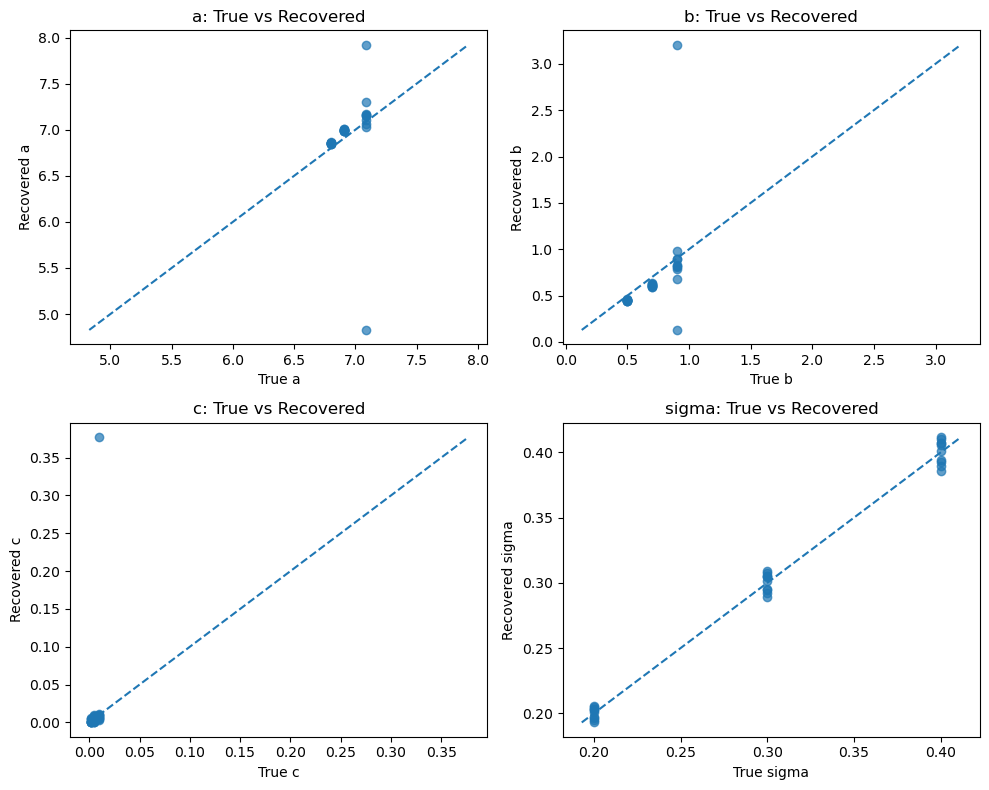

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, parameter in zip(axes.flatten(), parameters):

    ax.scatter(
        recovery_df[f"true_{parameter}"],
        recovery_df[f"recovered_{parameter}"],
        alpha=0.7
    )

    min_value = min(
        recovery_df[f"true_{parameter}"].min(),
        recovery_df[f"recovered_{parameter}"].min()
    )

    max_value = max(
        recovery_df[f"true_{parameter}"].max(),
        recovery_df[f"recovered_{parameter}"].max()
    )

    ax.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    ax.set_xlabel(f"True {parameter}")
    ax.set_ylabel(f"Recovered {parameter}")
    ax.set_title(f"{parameter}: True vs Recovered")

plt.tight_layout()
plt.show()

##### Interpretation

Parameter recovery assesses whether the fitting procedure can recover the parameters used to generate synthetic reaction-time data. Strong agreement between the true and recovered values indicates that the Exponential Indifference Model is practically identifiable under the simulated conditions.

## 8. Test–Retest Reliability

Test–retest reliability evaluates the stability of the Exponential Indifference Model parameters across the two experimental runs.

In [31]:
reliability_results = []

for participant_id, participant_data in participants.items():

    run_a = participant_data["train"].copy()
    run_b = participant_data["test"].copy()

    run_a = add_subjective_values(run_a, k=0.01)
    run_b = add_subjective_values(run_b, k=0.01)

    run_a = run_a.dropna(
        subset=["RT", "value_difference"]
    )

    run_b = run_b.dropna(
        subset=["RT", "value_difference"]
    )

    if len(run_a) < 20 or len(run_b) < 20:
        continue

    fit_a = fit_exponential_rt_model(run_a)
    fit_b = fit_exponential_rt_model(run_b)

    if not fit_a.success or not fit_b.success:
        continue

    a_a, b_a, c_a, sigma_a = fit_a.x
    a_b, b_b, c_b, sigma_b = fit_b.x

    reliability_results.append({
        "participant": participant_id,

        "a_run_a": a_a,
        "b_run_a": b_a,
        "c_run_a": c_a,
        "sigma_run_a": sigma_a,

        "a_run_b": a_b,
        "b_run_b": b_b,
        "c_run_b": c_b,
        "sigma_run_b": sigma_b
    })

reliability_df = pd.DataFrame(reliability_results)

print(
    "Participants with successful fits:",
    len(reliability_df)
)

Participants with successful fits: 99


In [32]:
reliability_parameters = ["a", "b", "c", "sigma"]

reliability_summary = []

for parameter in reliability_parameters:

    r, p = pearsonr(
        reliability_df[f"{parameter}_run_a"],
        reliability_df[f"{parameter}_run_b"]
    )

    reliability_summary.append({
        "parameter": parameter,
        "pearson_r": r,
        "p_value": p
    })

reliability_summary_df = pd.DataFrame(
    reliability_summary
)

reliability_summary_df

,parameter,pearson_r,p_value
0,a,-0.122803,2.259153e-01
1,b,-0.027839,7.844427e-01
2,c,0.148465,1.424890e-01
3,sigma,0.533749,1.278952e-08


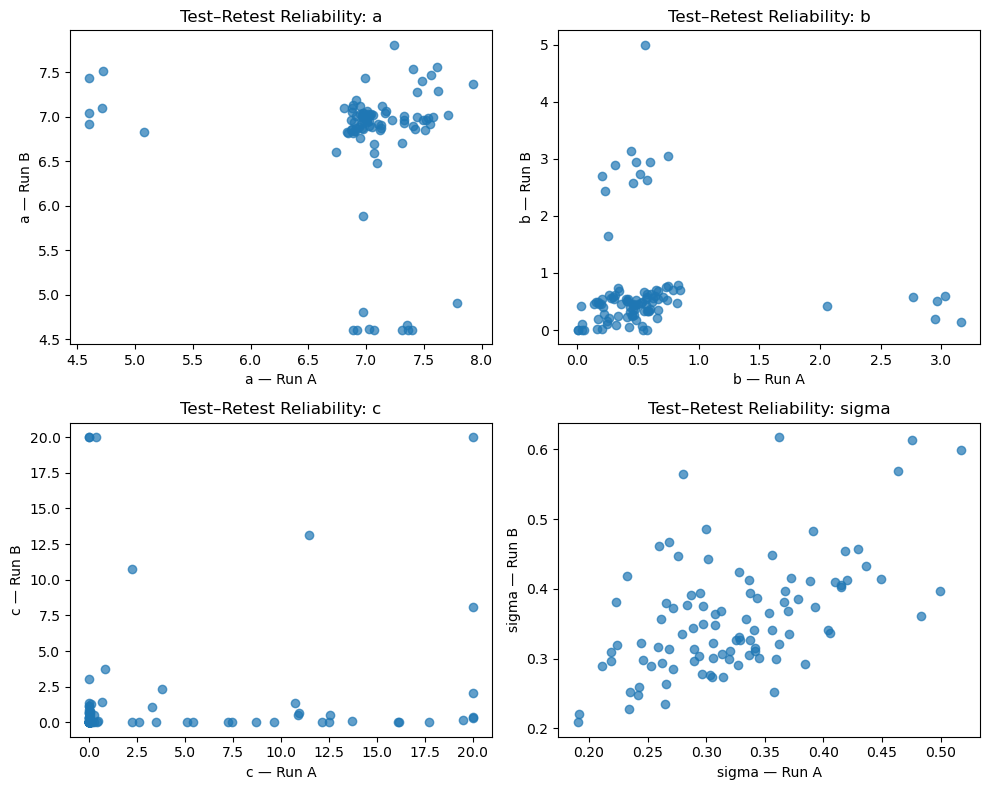

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, parameter in zip(
    axes.flatten(),
    reliability_parameters
):

    ax.scatter(
        reliability_df[f"{parameter}_run_a"],
        reliability_df[f"{parameter}_run_b"],
        alpha=0.7
    )

    ax.set_xlabel(f"{parameter} — Run A")
    ax.set_ylabel(f"{parameter} — Run B")
    ax.set_title(
        f"Test–Retest Reliability: {parameter}"
    )

plt.tight_layout()
plt.show()

##### Interpretation

Test–retest reliability indicates how consistently the Exponential Indifference Model estimates the same parameters across the two experimental runs. Higher cross-run correlations indicate greater stability of the corresponding parameter estimates, whereas weak correlations indicate substantial variation between runs.

## 9. Joint Choice–RT Model

The Exponential Indifference Model is also evaluated as part of a joint choice–reaction-time framework.

In [34]:
def predict_choice_probability(value_difference, beta):
    value_difference = np.asarray(value_difference)

    return 1 / (
        1 + np.exp(
            -beta * value_difference
        )
    )

In [35]:
def joint_negative_log_likelihood(params, df):

    beta, a, b, c, sigma = params

    if beta <= 0 or sigma <= 0:
        return np.inf

    choice_probability = predict_choice_probability(
        df["value_difference"].to_numpy(),
        beta
    )

    choice_probability = np.clip(
        choice_probability,
        1e-10,
        1 - 1e-10
    )

    choice = (
        df["choice"].to_numpy() == 1
    ).astype(int)

    log_likelihood_choice = (
        choice * np.log(choice_probability)
        +
        (1 - choice)
        * np.log(1 - choice_probability)
    )

    observed_rt = df["RT"].to_numpy()

    if np.any(observed_rt <= 0):
        return np.inf

    observed_log_rt = np.log(observed_rt)

    predicted_log_rt = predict_log_rt_exponential(
        df["value_difference"].to_numpy(),
        a,
        b,
        c
    )

    residuals = (
        observed_log_rt
        - predicted_log_rt
    )

    log_likelihood_rt = (
        -np.log(sigma)
        -0.5 * np.log(2 * np.pi)
        -(
            residuals ** 2
        ) / (
            2 * sigma ** 2
        )
    )

    total_log_likelihood = (
        log_likelihood_choice
        +
        log_likelihood_rt
    )

    return -np.sum(
        total_log_likelihood
    )

In [36]:
joint_data = combined_train.dropna(
    subset=[
        "choice",
        "RT",
        "value_difference"
    ]
).copy()

joint_data = joint_data[
    joint_data["RT"] > 0
].copy()

print(
    "Observations used for joint modelling:",
    len(joint_data)
)

Observations used for joint modelling: 8886


In [37]:
joint_initial = [
    1.0,
    exp_a,
    exp_b,
    exp_c,
    exp_sigma
]

joint_result = minimize(
    joint_negative_log_likelihood,

    x0=joint_initial,

    args=(joint_data,),

    method="L-BFGS-B",

    bounds=[
        (0.001, 20),
        (np.log(100), np.log(5000)),
        (0.001, 5),
        (0.0001, 20),
        (0.01, 2)
    ]
)

print(
    "Optimization successful:",
    joint_result.success
)

print(
    "Message:",
    joint_result.message
)

Optimization successful: True
Message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


In [38]:
joint_beta, joint_a, joint_b, joint_c, joint_sigma = (
    joint_result.x
)

print("Joint-model parameters:")

print(
    f"beta  = {joint_beta:.4f}"
)

print(
    f"a     = {joint_a:.6f}  (log-RT scale)"
)

print(
    f"b     = {joint_b:.6f}  (log-RT scale)"
)

print(
    f"c     = {joint_c:.6f}"
)

print(
    f"sigma = {joint_sigma:.6f}  (log-RT scale)"
)

Joint-model parameters:
beta  = 0.0010
a     = 7.429354  (log-RT scale)
b     = 0.155439  (log-RT scale)
c     = 10.388697
sigma = 0.407834  (log-RT scale)


In [39]:
joint_test = combined_test.dropna(
    subset=[
        "choice",
        "RT",
        "value_difference"
    ]
).copy()

joint_test["predicted_choice_probability"] = (
    predict_choice_probability(
        joint_test["value_difference"].to_numpy(),
        joint_beta
    )
)

joint_test["predicted_RT_joint"] = predict_rt_exponential(
    joint_test["value_difference"],
    joint_a,
    joint_b,
    joint_c,
    joint_sigma
)

print(
    "Joint-model test observations:",
    len(joint_test)
)

Joint-model test observations: 19952


In [40]:
from sklearn.metrics import log_loss, accuracy_score

choice_true = (
    joint_test["choice"] == 1
).astype(int)

choice_probability = np.clip(
    joint_test["predicted_choice_probability"],
    1e-10,
    1 - 1e-10
)

choice_log_loss = log_loss(
    choice_true,
    choice_probability
)

choice_accuracy = accuracy_score(
    choice_true,
    choice_probability >= 0.5
)

print(f"Choice log-loss: {choice_log_loss:.4f}")
print(f"Choice accuracy: {choice_accuracy:.4f}")

Choice log-loss: 0.6942
Choice accuracy: 0.4109


In [41]:
rt_true = joint_test["RT"]
rt_pred = joint_test["predicted_RT_joint"]

joint_rt_mae = mean_absolute_error(
    rt_true,
    rt_pred
)

joint_rt_rmse = np.sqrt(
    mean_squared_error(
        rt_true,
        rt_pred
    )
)

joint_rt_r2 = r2_score(
    rt_true,
    rt_pred
)

print(f"Joint RT MAE:  {joint_rt_mae:.2f} ms")
print(f"Joint RT RMSE: {joint_rt_rmse:.2f} ms")
print(f"Joint RT R²:   {joint_rt_r2:.4f}")

Joint RT MAE:  688.94 ms
Joint RT RMSE: 932.95 ms
Joint RT R²:   -0.0236


### 10. Psychological Hypothesis

The Exponential Indifference Model assumes that decisions are more difficult
when the subjective values of the two options are similar. Therefore, reaction
times are expected to be longest near subjective indifference
(\(|\Delta SV| \approx 0\)) and to decrease as the subjective value difference
increases, because larger value differences make the preferred option easier
to distinguish.